# Pairs Trading Across Sector ETFs: Mean Reversion from Weighting & Flow Frictions

**MGMTMFE-413 Statistical Arbitrage Research Project**

## Project Overview

This notebook implements a comprehensive pairs trading strategy on same-sector ETF pairs that:
- Uses time-varying hedge ratios via Kalman filtering
- Models spread mean reversion as an OU/AR(1) process
- Conditions signals on flow differentials and holdings overlap
- Implements robust backtesting with purged & embargoed walk-forward validation
- Includes robustness checks (SPA test, structural breaks, event studies)

## Table of Contents

1. [Setup and Configuration](#setup)
2. [Data Loading and Preprocessing](#data)
3. [Hedge Ratio Estimation (Kalman Filter)](#kalman)
4. [Mean Reversion Analysis](#meanrev)
5. [Signal Generation](#signals)
6. [Backtesting](#backtest)
7. [Performance Evaluation](#performance)
8. [Robustness Checks](#robustness)
9. [Results and Interpretation](#results)



## 1. Setup and Configuration {#setup}


In [5]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import config
from data_loader import ETFDataLoader
from wrds_loader import WRDSETFLoader, load_etf_pairs_from_wrds
from kalman_filter import KalmanFilter, estimate_hedge_ratio_kalman
from mean_reversion import estimate_ar1, rolling_ar1, adf_test, compute_mean_reversion_metrics
from signal_generation import generate_signals, compute_position_sizes, compute_zscore
from backtesting import WalkForwardBacktest, run_backtest
from performance import compute_performance_metrics, compute_rolling_metrics
from robustness import (
    spa_test, detect_structural_breaks, event_study,
    identify_large_flow_events, compute_robustness_checks
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"ETF Pairs: {config.ETF_PAIRS}")


✓ Imports successful
Project root: /Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project
ETF Pairs: [('XLE', 'VDE', 'Energy'), ('XLK', 'FTEC', 'Technology'), ('XLF', 'VFH', 'Financials'), ('XLI', 'VIS', 'Industrials'), ('XLV', 'VHT', 'Healthcare')]


## 2. Data Loading and Preprocessing {#data}

**Note:** This section assumes you have data files or will connect to WRDS/Refinitiv.
For demonstration, we'll show the structure and provide placeholder code.


In [6]:
# Load all ETF pairs from WRDS
from wrds_loader import WRDSETFLoader

# Initialize WRDS loader
wrds_username = 'chalakorn'
loader = WRDSETFLoader(wrds_username=wrds_username, data_dir='data/raw')

print("="*70)
print("Loading All ETF Pairs from WRDS")
print("="*70)
print(f"Date range: {config.START_DATE} to {config.END_DATE}")
print(f"Total pairs to load: {len(config.ETF_PAIRS)}\n")

# Get all unique symbols first
all_symbols = set()
for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    all_symbols.add(symbol_a)
    all_symbols.add(symbol_b)

print(f"Step 1: Loading {len(all_symbols)} unique ETFs...")
print("-"*70)

# Load all unique ETFs first
loaded_symbols = {}
for symbol in sorted(all_symbols):
    print(f"  Loading {symbol}...", end=" ")
    try:
        data = loader.load_etf_price_data_wrds(
            symbol,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        if not data.empty:
            loaded_symbols[symbol] = data
            date_range = f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}"
            print(f"✓ {len(data)} days ({date_range})")
        else:
            print(f"✗ No data returned")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Successfully loaded {len(loaded_symbols)}/{len(all_symbols)} ETFs")

# Step 2: Create pair datasets
print(f"\nStep 2: Creating {len(config.ETF_PAIRS)} pair datasets...")
print("-"*70)

pair_datasets = {}
pair_summary = []

for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    print(f"\n  Pair: {symbol_a} - {symbol_b} ({sector})")
    
    # Check if both ETFs are loaded
    if symbol_a not in loaded_symbols:
        print(f"    ✗ {symbol_a} not loaded - skipping pair")
        continue
    if symbol_b not in loaded_symbols:
        print(f"    ✗ {symbol_b} not loaded - skipping pair")
        continue
    
    try:
        # Create pair dataset
        pair_data = loader.create_pair_dataset(
            symbol_a, symbol_b,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        
        if not pair_data.empty:
            pair_data['sector'] = sector
            pair_datasets[(symbol_a, symbol_b)] = pair_data
            
            # Summary info
            date_range = f"{pair_data.index.min().strftime('%Y-%m-%d')} to {pair_data.index.max().strftime('%Y-%m-%d')}"
            print(f"    ✓ Created pair dataset: {len(pair_data)} days ({date_range})")
            
            pair_summary.append({
                'Pair': f"{symbol_a}-{symbol_b}",
                'Sector': sector,
                'Days': len(pair_data),
                'Start': pair_data.index.min().strftime('%Y-%m-%d'),
                'End': pair_data.index.max().strftime('%Y-%m-%d')
            })
        else:
            print(f"    ✗ No overlapping data between {symbol_a} and {symbol_b}")
            
    except Exception as e:
        import traceback
        print(f"    ✗ Error creating pair: {str(e)[:100]}")
        print(f"    {traceback.format_exc()[:200]}")

# Close WRDS connection
loader.close()

# Final summary
print("\n" + "="*70)
print("LOADING SUMMARY")
print("="*70)
print(f"ETFs loaded: {len(loaded_symbols)}/{len(all_symbols)}")
print(f"Pairs created: {len(pair_datasets)}/{len(config.ETF_PAIRS)}")

if pair_summary:
    summary_df = pd.DataFrame(pair_summary)
    print("\nPair datasets:")
    display(summary_df)
    
    # Save summary
    summary_df.to_csv('pair_summary.csv', index=False)
    print("\n✓ Summary saved to results/pair_summary.csv")

# Store pair_datasets for use in subsequent cells
print(f"\n✓ Data loading complete!")
print(f"  Use 'pair_datasets' dictionary to access pair data")
print(f"  Example: pair_data = pair_datasets[('XLE', 'VDE')]")


Loading library list...
Done
✓ WRDS connection established
Loading All ETF Pairs from WRDS
Date range: 2010-01-01 to 2024-12-31
Total pairs to load: 5

Step 1: Loading 10 unique ETFs...
----------------------------------------------------------------------
  Loading FTEC...     Using permno 14205 for FTEC
    ✓ Loaded 2815 rows from dsf
✓ 2815 days (2013-10-24 to 2024-12-31)
  Loading VDE...     Using permno 90347 for VDE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VFH...     Using permno 89994 for VFH
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VHT...     Using permno 89995 for VHT
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VIS...     Using permno 90348 for VIS
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLE...     Using permno 86454 for XLE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLF...     Using 

,Pair,Sector,Days,Start,End
0,XLE-VDE,Energy,3774,2010-01-04,2024-12-31
1,XLK-FTEC,Technology,2815,2013-10-24,2024-12-31
2,XLF-VFH,Financials,3774,2010-01-04,2024-12-31
3,XLI-VIS,Industrials,3774,2010-01-04,2024-12-31
4,XLV-VHT,Healthcare,3774,2010-01-04,2024-12-31



✓ Summary saved to results/pair_summary.csv

✓ Data loading complete!
  Use 'pair_datasets' dictionary to access pair data
  Example: pair_data = pair_datasets[('XLE', 'VDE')]


In [7]:
# Save each pair_data DataFrame to a separate CSV file
import os

output_dir = "pair_data_csv"
os.makedirs(output_dir, exist_ok=True)

for (symbol_a, symbol_b), pair_data in pair_datasets.items():
    filename = f"{symbol_a}-{symbol_b}.csv"
    filepath = os.path.join(output_dir, filename)
    pair_data.to_csv(filepath)
    print(f"Saved {filename} to {output_dir}/")


Saved XLE-VDE.csv to pair_data_csv/
Saved XLK-FTEC.csv to pair_data_csv/
Saved XLF-VFH.csv to pair_data_csv/
Saved XLI-VIS.csv to pair_data_csv/
Saved XLV-VHT.csv to pair_data_csv/


## 3. Hedge Ratio Estimation (Kalman Filter) {#kalman}

Estimate time-varying hedge ratio using Kalman filter.


In [8]:
# Example workflow for Kalman filter estimation
# Assuming pair_data is loaded

def estimate_pair_hedge_ratio(symbol_a, symbol_b, pair_data):
    """
    Estimate hedge ratio for an ETF pair.
    
    This is a template - replace with actual data loading.
    """
    # Extract log prices
    log_price_a = pair_data['log_price_A']
    log_price_b = pair_data['log_price_B']
    
    # Run Kalman filter
    kalman_result = estimate_hedge_ratio_kalman(
        pair_data,
        config=config.KALMAN_CONFIG
    )
    
    return kalman_result

# Example usage (uncomment when data is loaded):
pair_data = loader.create_pair_dataset('XLE', 'VDE', 
                                      start_date=config.START_DATE,
                                      end_date=config.END_DATE)
kalman_results = estimate_pair_hedge_ratio('XLE', 'VDE', pair_data)

print("Kalman filter estimation function ready.")
print("\nKey outputs:")
print("- beta_smoothed: Time-varying hedge ratio")
print("- spread: Spread series s_t = log_price_A - beta_t * log_price_B")


Kalman filter estimation function ready.

Key outputs:
- beta_smoothed: Time-varying hedge ratio
- spread: Spread series s_t = log_price_A - beta_t * log_price_B


In [9]:
kalman_results

,beta_filtered,beta_variance_filtered,beta_smoothed,beta_variance_smoothed,spread
date,,,,,
2010-01-04,0.915177,0.000050,0.915177,0.000050,-0.001886
2010-01-05,0.914660,0.000038,0.914660,0.000038,-0.000771
2010-01-06,0.914769,0.000037,0.914769,0.000037,0.000176
2010-01-07,0.914910,0.000037,0.914910,0.000037,0.000231
2010-01-08,0.914887,0.000036,0.914887,0.000036,-0.000038
...,...,...,...,...,...
2024-12-24,0.928136,0.000033,0.928136,0.000033,-0.000152
2024-12-26,0.928129,0.000033,0.928129,0.000033,-0.000011
2024-12-27,0.928084,0.000033,0.928084,0.000033,-0.000071


## 4. Mean Reversion Analysis {#meanrev}

Model spread as AR(1) process and compute half-life.


In [10]:
# Example mean reversion analysis
# Assuming spread is computed from Kalman filter

def analyze_mean_reversion(spread):
    """
    Analyze mean reversion properties of spread.
    """
    # Compute comprehensive metrics
    metrics = compute_mean_reversion_metrics(
        spread,
        config=config.MEAN_REVERSION_CONFIG
    )
    
    # Rolling AR(1) estimation
    rolling_ar1_results = rolling_ar1(
        spread,
        window=config.MEAN_REVERSION_CONFIG['ar1_window']
    )
    
    return metrics, rolling_ar1_results

# Example usage:
metrics, rolling = analyze_mean_reversion(kalman_results['spread'])

print("Mean reversion analysis functions ready.")
print("\nKey metrics:")
print("- mu: Mean reversion level")
print("- phi: AR(1) coefficient")
print("- half_life: Half-life in days")
print("- is_stationary: ADF test result")


Mean reversion analysis functions ready.

Key metrics:
- mu: Mean reversion level
- phi: AR(1) coefficient
- half_life: Half-life in days
- is_stationary: ADF test result


## 5. Signal Generation {#signals}

Generate trading signals with z-scores and flow/weighting conditions.


In [11]:
# Signal generation example

def generate_pair_signals(pair_data, spread, signal_config=None):
    """
    Generate trading signals for a pair.
    """
    if signal_config is None:
        signal_config = config.SIGNAL_CONFIG
    
    # Generate signals
    signals = generate_signals(pair_data, spread, signal_config)
    
    # Compute position sizes
    signals = compute_position_sizes(
        signals,
        pair_data,
        config.BACKTEST_CONFIG
    )
    
    return signals

# Example usage:
signals = generate_pair_signals(pair_data, kalman_results['spread'])

print("Signal generation functions ready.")
print("\nSignal logic:")
print("- Enter long when z-score < -z_entry AND flow condition met")
print("- Enter short when z-score > +z_entry AND flow condition met")
print("- Exit when |z-score| < z_exit OR max holding period OR stop loss")


Signal generation functions ready.

Signal logic:
- Enter long when z-score < -z_entry AND flow condition met
- Enter short when z-score > +z_entry AND flow condition met
- Exit when |z-score| < z_exit OR max holding period OR stop loss


In [38]:
signals

,spread,zscore,flow_diff,flow_diff_pct,flow_diff_pctile,signal,position,entry_date,entry_zscore,entry_spread,days_held,position_size_A,position_size_B,notional
date,,,,,,,,,,,,,,
2010-01-04,-0.001886,<NA>,0.0,0.0,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-05,-0.000771,<NA>,0.0,-0.002074,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-06,0.000176,<NA>,0.0,0.000461,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-07,0.000231,<NA>,0.0,0.00089,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-08,-0.000038,<NA>,0.0,-0.001021,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,-0.000152,-0.189924,0.0,0.000778,0.501984,-1,0,NaT,NaN,NaN,1,0.0,0.0,0.0
2024-12-26,-0.000011,0.149007,0.0,0.000178,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2024-12-27,-0.000071,0.026013,0.0,-0.000286,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0


## 6. Portfolio Construction and Optimization {#portfolio}

Load all pair CSV files, process each pair (Kalman filter, signals, returns), and optimize portfolio weights and hedge ratios.


In [46]:
# Import portfolio optimization module
from portfolio_optimization import (
    optimize_portfolio_weights,
    optimize_hedge_ratios,
    compute_portfolio_returns
)

# Define helper function for computing strategy returns
def compute_strategy_returns(signals, pair_data):
    """
    Compute strategy returns from signals and pair data (without transaction costs).
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: position_size_A, position_size_B
        (dollar positions in ETF A and ETF B)
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
        (returns for ETF A and ETF B)
    
    Returns:
    --------
    pd.Series : Strategy returns (same index as common dates)
    """
    # Align data on common dates
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get position sizes and returns
    pos_a = signals.loc[common_idx, 'position_size_A']
    pos_b = signals.loc[common_idx, 'position_size_B']
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Compute dollar P&L: positions * returns
    dollar_pnl = pos_a * returns_a + pos_b * returns_b
    
    # Compute notional (total exposure) for normalization
    notional = pos_a.abs() + pos_b.abs()
    
    # Normalize by notional to get returns
    # Use previous period's notional to avoid look-ahead bias
    prev_notional = notional.shift(1).fillna(notional)
    
    # Avoid division by zero
    strategy_returns = dollar_pnl / prev_notional.replace(0, np.nan)
    strategy_returns = strategy_returns.fillna(0.0)
    
    return strategy_returns

print("✓ Portfolio optimization module imported")
print("✓ Helper functions defined")


✓ Portfolio optimization module imported
✓ Helper functions defined


In [47]:
# Load all pair CSV files
import os

pair_data_dir = "pair_data_csv"
pair_files = {
    'XLE-VDE': 'XLE-VDE.csv',
    'XLK-FTEC': 'XLK-FTEC.csv',
    'XLF-VFH': 'XLF-VFH.csv',
    'XLI-VIS': 'XLI-VIS.csv',
    'XLV-VHT': 'XLV-VHT.csv'
}

# Load all pair data
pair_data_dict = {}
for pair_name, filename in pair_files.items():
    filepath = os.path.join(pair_data_dir, filename)
    if os.path.exists(filepath):
        df = pd.read_csv(filepath, index_col='date', parse_dates=True)
        pair_data_dict[pair_name] = df
        print(f"✓ Loaded {pair_name}: {len(df)} days ({df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')})")
    else:
        print(f"✗ File not found: {filepath}")

print(f"\n✓ Loaded {len(pair_data_dict)}/{len(pair_files)} pairs")


✓ Loaded XLE-VDE: 3774 days (2010-01-04 to 2024-12-31)
✓ Loaded XLK-FTEC: 2815 days (2013-10-24 to 2024-12-31)
✓ Loaded XLF-VFH: 3774 days (2010-01-04 to 2024-12-31)
✓ Loaded XLI-VIS: 3774 days (2010-01-04 to 2024-12-31)
✓ Loaded XLV-VHT: 3774 days (2010-01-04 to 2024-12-31)

✓ Loaded 5/5 pairs


In [48]:
# Process each pair: Kalman filter, signals, and strategy returns
pair_results = {}

print("="*70)
print("Processing All Pairs")
print("="*70)

for pair_name, pair_data in pair_data_dict.items():
    print(f"\nProcessing {pair_name}...")
    
    try:
        # 1. Kalman filter to estimate hedge ratio
        print(f"  Step 1: Running Kalman filter...")
        kalman_result = estimate_hedge_ratio_kalman(pair_data, config=config.KALMAN_CONFIG)
        spread = kalman_result['spread']
        beta_smoothed = kalman_result['beta_smoothed']
        
        # 2. Generate signals
        print(f"  Step 2: Generating signals...")
        signals = generate_signals(pair_data, spread, config.SIGNAL_CONFIG)
        signals = compute_position_sizes(signals, pair_data, config.BACKTEST_CONFIG)
        
        # 3. Compute strategy returns
        print(f"  Step 3: Computing strategy returns...")
        strategy_returns = compute_strategy_returns(signals, pair_data)
        
        # Store results
        pair_results[pair_name] = {
            'pair_data': pair_data,
            'kalman_result': kalman_result,
            'spread': spread,
            'beta_smoothed': beta_smoothed,
            'signals': signals,
            'strategy_returns': strategy_returns
        }
        
        # Compute basic metrics
        ann_ret = strategy_returns.mean() * 252
        ann_vol = strategy_returns.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
        
        print(f"  ✓ Complete: Sharpe={sharpe:.3f}, AnnRet={ann_ret:.2%}, AnnVol={ann_vol:.2%}")
        
    except Exception as e:
        print(f"  ✗ Error processing {pair_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Processed {len(pair_results)}/{len(pair_data_dict)} pairs successfully")


Processing All Pairs

Processing XLE-VDE...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.128, AnnRet=0.05%, AnnVol=0.39%

Processing XLK-FTEC...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=-0.145, AnnRet=-0.06%, AnnVol=0.40%

Processing XLF-VFH...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.292, AnnRet=0.13%, AnnVol=0.43%

Processing XLI-VIS...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.373, AnnRet=0.11%, AnnVol=0.29%

Processing XLV-VHT...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.215, AnnRet=0.09%, AnnVol=0.41%

✓ Processed 5/5 pairs successfully


In [49]:
# Extract strategy returns for all pairs
pair_returns_dict = {
    pair_name: results['strategy_returns'] 
    for pair_name, results in pair_results.items()
}

# Display summary statistics
returns_df = pd.DataFrame(pair_returns_dict)
returns_df = returns_df.dropna()

print("Strategy Returns Summary:")
print("="*70)
print(returns_df.describe())
print(f"\nCommon date range: {returns_df.index.min().strftime('%Y-%m-%d')} to {returns_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total periods: {len(returns_df)}")


Strategy Returns Summary:
           XLE-VDE     XLK-FTEC      XLF-VFH      XLI-VIS      XLV-VHT
count  2815.000000  2815.000000  2815.000000  2815.000000  2815.000000
mean      0.000002    -0.000002     0.000005     0.000003     0.000004
std       0.000275     0.000252     0.000273     0.000188     0.000279
min      -0.002876    -0.003048    -0.003743    -0.001922    -0.002300
25%       0.000000     0.000000     0.000000     0.000000     0.000000
50%       0.000000     0.000000     0.000000     0.000000     0.000000
75%       0.000000     0.000000     0.000000     0.000000     0.000000
max       0.007236     0.002698     0.007360     0.001950     0.005978

Common date range: 2013-10-24 to 2024-12-31
Total periods: 2815


In [50]:
# Optimize portfolio weights
print("="*70)
print("Portfolio Weight Optimization")
print("="*70)

# Set constraints
weight_constraints = {
    'min_weight': 0.0,      # Allow short positions (negative weights)
    'max_weight': 1.0,      # Maximum weight per pair
    'sum_to_one': True,     # Weights sum to 1
    'max_leverage': None    # No leverage constraint (can set to 2.0 for 2x leverage)
}

# Optimize for maximum Sharpe ratio
print("\nOptimizing for maximum Sharpe ratio...")
opt_result = optimize_portfolio_weights(
    pair_returns_dict,
    objective='sharpe',
    constraints=weight_constraints,
    method='SLSQP'
)

optimal_weights = opt_result['weights']
portfolio_returns = opt_result['portfolio_returns']
portfolio_metrics = opt_result['metrics']

print("\nOptimal Portfolio Weights:")
print("-"*70)
for pair_name, weight in sorted(optimal_weights.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")

print("\nPortfolio Performance Metrics:")
print("-"*70)
for metric, value in portfolio_metrics.items():
    if isinstance(value, float):
        if 'return' in metric.lower() or 'sharpe' in metric.lower():
            print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value:10.4f}")
    else:
        print(f"  {metric:25s}: {value}")

# Store results
portfolio_results = {
    'optimal_weights': optimal_weights,
    'portfolio_returns': portfolio_returns,
    'portfolio_metrics': portfolio_metrics,
    'optimization_result': opt_result
}


Portfolio Weight Optimization

Optimizing for maximum Sharpe ratio...

Optimal Portfolio Weights:
----------------------------------------------------------------------
  XLI-VIS     :   0.3600 ( 36.00%)
  XLF-VFH     :   0.3168 ( 31.68%)
  XLV-VHT     :   0.1839 ( 18.39%)
  XLE-VDE     :   0.1393 ( 13.93%)
  XLK-FTEC    :   0.0000 (  0.00%)

Portfolio Performance Metrics:
----------------------------------------------------------------------
  annualized_return        :     0.0009 (0.09%)
  annualized_volatility    :     0.0021
  sharpe_ratio             :     0.4323 (43.23%)
  total_return             :     0.0103 (1.03%)
  max_drawdown             :    -0.0027
  n_periods                : 2815


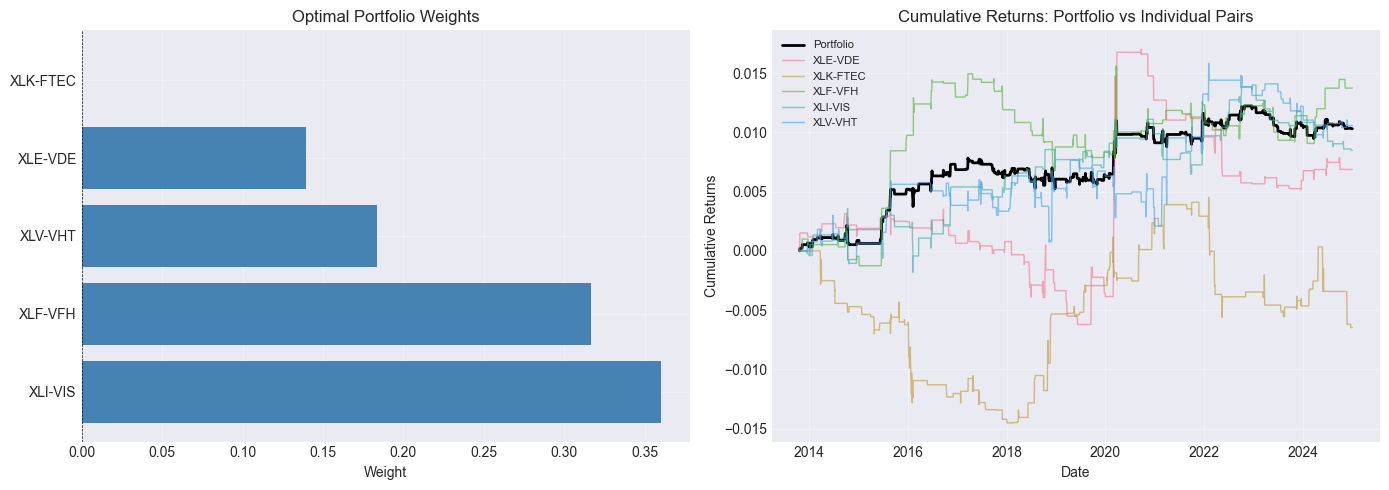

In [51]:
# Visualize portfolio weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weights bar chart
weights_df = pd.Series(optimal_weights)
weights_df = weights_df.sort_values(key=abs, ascending=False)

axes[0].barh(range(len(weights_df)), weights_df.values, color='steelblue')
axes[0].set_yticks(range(len(weights_df)))
axes[0].set_yticklabels(weights_df.index)
axes[0].set_xlabel('Weight')
axes[0].set_title('Optimal Portfolio Weights')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Portfolio returns vs individual pair returns
axes[1].plot(portfolio_returns.cumsum(), label='Portfolio', linewidth=2, color='black')
for pair_name, returns in pair_returns_dict.items():
    aligned_returns = returns.reindex(portfolio_returns.index, fill_value=0)
    axes[1].plot(aligned_returns.cumsum(), label=pair_name, alpha=0.6, linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Returns')
axes[1].set_title('Cumulative Returns: Portfolio vs Individual Pairs')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [52]:
# Optimize hedge ratios (Kalman filter parameters) for each pair
print("="*70)
print("Hedge Ratio Optimization (Kalman Filter Parameters)")
print("="*70)
print("\nNote: This optimization can be time-consuming. It optimizes observation_noise,")
print("state_noise, and initial_beta for each pair to maximize Sharpe ratio.\n")

# Option to skip optimization (set to True to skip)
SKIP_HEDGE_OPTIMIZATION = False

if not SKIP_HEDGE_OPTIMIZATION:
    optimized_hedge_results = {}
    
    for pair_name, pair_data in pair_data_dict.items():
        print(f"\nOptimizing hedge ratio for {pair_name}...")
        
        try:
            # Set parameter bounds for optimization
            param_bounds = {
                'observation_noise': (0.0001, 0.01),
                'state_noise': (0.00001, 0.001),
                'initial_beta': (0.5, 1.5)
            }
            
            # Optimize
            hedge_opt_result = optimize_hedge_ratios(
                pair_data,
                kalman_config=config.KALMAN_CONFIG,
                objective='sharpe',
                param_bounds=param_bounds
            )
            
            optimized_hedge_results[pair_name] = hedge_opt_result
            
            # Display results
            opt_config = hedge_opt_result['optimal_config']
            metrics = hedge_opt_result['metrics']
            
            print(f"  Optimal parameters:")
            print(f"    observation_noise: {opt_config['observation_noise']:.6f}")
            print(f"    state_noise: {opt_config['state_noise']:.6f}")
            print(f"    initial_beta: {opt_config['initial_beta']:.4f}")
            print(f"  Performance: Sharpe={metrics['sharpe_ratio']:.3f}, "
                  f"AnnRet={metrics['annualized_return']:.2%}")
            
        except Exception as e:
            print(f"  ✗ Error optimizing {pair_name}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    print(f"\n✓ Optimized hedge ratios for {len(optimized_hedge_results)} pairs")
    
    # Compare original vs optimized
    print("\n" + "="*70)
    print("Comparison: Original vs Optimized Hedge Ratios")
    print("="*70)
    
    comparison_data = []
    for pair_name in pair_results.keys():
        if pair_name in optimized_hedge_results:
            orig_metrics = compute_performance_metrics(pair_results[pair_name]['strategy_returns'])
            opt_metrics = optimized_hedge_results[pair_name]['metrics']
            
            comparison_data.append({
                'Pair': pair_name,
                'Original_Sharpe': orig_metrics.get('sharpe_ratio', 0),
                'Optimized_Sharpe': opt_metrics.get('sharpe_ratio', 0),
                'Original_AnnRet': orig_metrics.get('annualized_return', 0),
                'Optimized_AnnRet': opt_metrics.get('annualized_return', 0),
                'Improvement_Sharpe': opt_metrics.get('sharpe_ratio', 0) - orig_metrics.get('sharpe_ratio', 0)
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        display(comparison_df)
        
        # Store optimized results
        for pair_name, result in optimized_hedge_results.items():
            pair_results[pair_name]['optimized_hedge'] = result
else:
    print("Skipping hedge ratio optimization (SKIP_HEDGE_OPTIMIZATION=True)")


Hedge Ratio Optimization (Kalman Filter Parameters)

Note: This optimization can be time-consuming. It optimizes observation_noise,
state_noise, and initial_beta for each pair to maximize Sharpe ratio.


Optimizing hedge ratio for XLE-VDE...


KeyboardInterrupt: 

In [ ]:
# Recompute portfolio with optimized hedge ratios (if optimization was run)
if not SKIP_HEDGE_OPTIMIZATION and 'optimized_hedge_results' in locals():
    print("="*70)
    print("Recomputing Portfolio with Optimized Hedge Ratios")
    print("="*70)
    
    # Extract optimized strategy returns
    optimized_pair_returns = {}
    for pair_name, result in optimized_hedge_results.items():
        optimized_pair_returns[pair_name] = result['strategy_returns']
    
    # Optimize portfolio weights again with optimized returns
    opt_result_optimized = optimize_portfolio_weights(
        optimized_pair_returns,
        objective='sharpe',
        constraints=weight_constraints,
        method='SLSQP'
    )
    
    optimal_weights_optimized = opt_result_optimized['weights']
    portfolio_returns_optimized = opt_result_optimized['portfolio_returns']
    portfolio_metrics_optimized = opt_result_optimized['metrics']
    
    print("\nOptimal Portfolio Weights (with optimized hedge ratios):")
    print("-"*70)
    for pair_name, weight in sorted(optimal_weights_optimized.items(), key=lambda x: abs(x[1]), reverse=True):
        print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")
    
    print("\nPortfolio Performance Metrics (with optimized hedge ratios):")
    print("-"*70)
    for metric, value in portfolio_metrics_optimized.items():
        if isinstance(value, float):
            if 'return' in metric.lower() or 'sharpe' in metric.lower():
                print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value}")
    
    # Compare
    print("\n" + "="*70)
    print("Comparison: Original Portfolio vs Optimized Portfolio")
    print("="*70)
    
    comparison = pd.DataFrame({
        'Original': portfolio_metrics,
        'Optimized': portfolio_metrics_optimized
    })
    display(comparison)
    
    # Store optimized portfolio results
    portfolio_results['optimized_hedge_weights'] = optimal_weights_optimized
    portfolio_results['optimized_hedge_returns'] = portfolio_returns_optimized
    portfolio_results['optimized_hedge_metrics'] = portfolio_metrics_optimized
else:
    print("Skipping portfolio recomputation (hedge ratio optimization was skipped)")


In [ ]:
# Summary: Display all results
print("="*70)
print("PORTFOLIO OPTIMIZATION SUMMARY")
print("="*70)

print("\n1. Individual Pair Performance:")
print("-"*70)
pair_summary = []
for pair_name, results in pair_results.items():
    returns = results['strategy_returns']
    ann_ret = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    total_ret = (1 + returns).prod() - 1
    
    pair_summary.append({
        'Pair': pair_name,
        'Sharpe': sharpe,
        'AnnReturn': ann_ret,
        'AnnVol': ann_vol,
        'TotalReturn': total_ret,
        'Weight': optimal_weights.get(pair_name, 0.0)
    })

pair_summary_df = pd.DataFrame(pair_summary)
display(pair_summary_df)

print("\n2. Portfolio Performance:")
print("-"*70)
for metric, value in portfolio_metrics.items():
    if isinstance(value, float):
        if 'return' in metric.lower() or 'sharpe' in metric.lower():
            print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value:10.4f}")
    else:
        print(f"  {metric:25s}: {value}")

print("\n✓ Portfolio optimization complete!")
print(f"  - Processed {len(pair_results)} pairs")
print(f"  - Optimal weights computed")
print(f"  - Portfolio Sharpe ratio: {portfolio_metrics['sharpe_ratio']:.3f}")
